# Working with Pandemic Data

This notebook evaluates six imputation methods for filling the COVID-19 gap in the Brazil tourism arrivals time series.

**Approach:** select multiple non-overlapping pre-COVID windows, mask each one to simulate a gap, fit/apply each method using only the data *before* (and where applicable *after*) the masked window, and measure reconstruction error against the ground truth.

**Methods compared:**
1. Linear interpolation (time-based)
2. STL + PCHIP — STL decomposition fitted on pre-gap data; seasonal component projected forward into the gap; PCHIP interpolation applied to the trend only, then seasonal added back
3. Spline interpolation (order=3)
4. Auto ARIMA — forward SARIMAX fitted on pre-gap data only
5. Auto ARIMA (backward) — SARIMAX fitted on *reversed* post-gap data, predictions re-reversed to chronological order
6. ARIMA blend — linear-decay weighted average of forward and backward ARIMA forecasts

**Metrics:** MAE, RMSE, MAPE

In [9]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pmdarima import auto_arima
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings('ignore')

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-01-01')
COVID_END = pd.Timestamp('2021-12-31')

sns.set_palette('colorblind')

## Data Import

In [10]:
df = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, 'train.parquet'))
df = df.set_index('date')

monthly_df = df[['arrival_count']].resample('ME').sum()

print(
    f'Series range : {monthly_df.index.min().date()} → {monthly_df.index.max().date()}'
)
print(f'Total months : {len(monthly_df)}')
monthly_df.head()

Series range : 1989-01-31 → 2024-12-31
Total months : 432


,arrival_count
date,
1989-01-31,291566.0
1989-02-28,197348.0
1989-03-31,149001.0
1989-04-30,84867.0
1989-05-31,69293.0


## Imputation Benchmark

### Test Windows

Four non-overlapping pre-COVID windows of 24 months each. All windows end early enough that ≥24 months of pre-COVID data remain after the gap, so the backward ARIMA model has at least two seasonal cycles to fit on.

| Window | Gap start | Gap end  | Post-gap span (pre-COVID) |
|--------|-----------|----------|---------------------------|
| W1     | 2010-01   | 2011-12  | 96 months |
| W2     | 2012-01   | 2013-12  | 72 months |
| W3     | 2014-01   | 2015-12  | 48 months |
| W4     | 2015-06   | 2016-06  | 24 months |

In [11]:
WINDOWS = [
    ('W1', pd.Timestamp('2010-01-01'), pd.Timestamp('2011-12-31')),
    ('W2', pd.Timestamp('2012-01-01'), pd.Timestamp('2013-12-31')),
    ('W3', pd.Timestamp('2014-01-01'), pd.Timestamp('2015-12-31')),
    ('W4', pd.Timestamp('2015-06-30'), pd.Timestamp('2016-06-30')),
]

for name, start, end in WINDOWS:
    n = monthly_df.loc[start:end].shape[0]
    print(f'{name}: {start.date()} → {end.date()} ({n} months)')

W1: 2010-01-01 → 2011-12-31 (24 months)
W2: 2012-01-01 → 2013-12-31 (24 months)
W3: 2014-01-01 → 2015-12-31 (24 months)
W4: 2015-06-30 → 2016-06-30 (13 months)


### Helper Functions

In [12]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def apply_linear(series_with_nan):
    return series_with_nan.interpolate(method='time').clip(lower=0)


def apply_stl_pchip(series_with_nan, gap_mask, pre_gap_end):
    "STL decomposition on pre-gap data; project seasonal forward; PCHIP the trend."
    pre_gap = series_with_nan[series_with_nan.index <= pre_gap_end].dropna()

    stl = STL(pre_gap, period=12, seasonal=13, robust=True)
    stl_res = stl.fit()

    # tile the last full year's seasonal pattern over the gap
    n_gap = int(gap_mask.sum())
    seasonal_pattern = stl_res.seasonal[-12:].values
    projected_seasonal = np.tile(seasonal_pattern, n_gap // 12 + 1)[:n_gap]

    # interpolate trend across the full series (gap included as NaN)
    trend_interp = series_with_nan.interpolate(method='pchip')

    result = series_with_nan.copy()
    result[gap_mask] = (trend_interp[gap_mask].values + projected_seasonal).clip(min=0)
    return result


def apply_spline(series_with_nan):
    return series_with_nan.interpolate(method='spline', order=3).clip(lower=0)


def apply_auto_arima(series_with_nan, gap_mask, pre_gap_end):
    "Fit SARIMAX on data strictly before the gap, forecast across the gap."
    pre_gap = series_with_nan[series_with_nan.index <= pre_gap_end].dropna()
    n_gap = int(gap_mask.sum())

    model = auto_arima(
        pre_gap,
        seasonal=True,
        m=12,
        stepwise=True,
        information_criterion='aic',
        error_action='ignore',
        suppress_warnings=True,
    )
    forecast = np.asarray(model.predict(n_periods=n_gap))
    result = series_with_nan.copy()
    result[gap_mask] = np.clip(forecast, 0, None)
    return result, model, forecast


def apply_auto_arima_bwd(series_with_nan, gap_mask, post_gap_start, post_gap_end):
    """Fit SARIMAX on *reversed* post-gap data, predict backward across the gap.

    The post-gap slice is reversed to a plain numpy array (avoids index-mismatch
    during fitting); the model learns trend/seasonality moving backward in time;
    the forecast is then reversed so it aligns chronologically with the gap.
    """
    post_gap = series_with_nan[
        (series_with_nan.index >= post_gap_start)
        & (series_with_nan.index <= post_gap_end)
    ].dropna()
    n_gap = int(gap_mask.sum())

    reversed_arr = post_gap.values[::-1]
    model = auto_arima(
        reversed_arr,
        seasonal=True,
        m=12,
        stepwise=True,
        information_criterion='aic',
        error_action='ignore',
        suppress_warnings=True,
    )
    forecast_bwd_raw = np.asarray(model.predict(n_periods=n_gap))
    forecast_bwd = forecast_bwd_raw[::-1]  # restore chronological order

    result = series_with_nan.copy()
    result[gap_mask] = np.clip(forecast_bwd, 0, None)
    return result, model, forecast_bwd


def apply_arima_blend(series_with_nan, gap_mask, forecast_fwd, forecast_bwd):
    """Linear-decay weighted average: 100% forward at gap start → 100% backward at gap end."""
    n_gap = int(gap_mask.sum())
    w = np.linspace(1.0, 0.0, n_gap)
    imputed = w * forecast_fwd + (1.0 - w) * forecast_bwd

    result = series_with_nan.copy()
    result[gap_mask] = np.clip(imputed, 0, None)
    return result


METHOD_STYLES = {
    'Linear': ('steelblue', '-'),
    'STL + PCHIP': ('darkorange', '-'),
    'Spline': ('seagreen', '-'),
    'Auto ARIMA (fwd)': ('mediumpurple', '-'),
    'Auto ARIMA (bwd)': ('crimson', '-'),
    'ARIMA blend': ('teal', '-'),
}

### Run Benchmark Across All Windows

In [13]:
records = []
window_results = {}  # stores imputed series per window for plotting

# Cap post-gap training data at the pre-COVID boundary so the backward model
# never sees the pandemic anomaly.
POST_GAP_CUTOFF = COVID_START - pd.Timedelta(days=1)

for win_name, gap_start, gap_end in WINDOWS:
    print(f'\n{"=" * 55}')
    print(f'  {win_name}: {gap_start.date()} → {gap_end.date()}')
    print(f'{"=" * 55}')

    gap_mask = (monthly_df.index >= gap_start) & (monthly_df.index <= gap_end)
    truth = monthly_df.loc[gap_mask, 'arrival_count'].values

    # Build a series with the gap masked as NaN
    masked = monthly_df['arrival_count'].copy()
    masked[gap_mask] = np.nan

    # Training cutoffs
    pre_gap_start = monthly_df.index[0]
    pre_gap_end = monthly_df[monthly_df.index < gap_start].index[-1]
    post_gap_start = monthly_df[monthly_df.index > gap_end].index[0]
    post_gap_end = POST_GAP_CUTOFF
    n_pre = monthly_df.loc[pre_gap_start:pre_gap_end].shape[0]
    n_post = monthly_df.loc[post_gap_start:post_gap_end].shape[0]
    print(
        f'  Pre-gap  training span: {pre_gap_start.date()} → {pre_gap_end.date()} ({n_pre} months)'
    )
    print(
        f'  Post-gap training span: {post_gap_start.date()} → {post_gap_end.date()} ({n_post} months)'
    )

    # Linear
    s_linear = apply_linear(masked)
    pred_linear = s_linear[gap_mask].values

    # STL + PCHIP
    s_stl_pchip = apply_stl_pchip(masked, gap_mask, pre_gap_end)
    pred_stl_pchip = s_stl_pchip[gap_mask].values

    # Spline
    s_spline = apply_spline(masked)
    pred_spline = s_spline[gap_mask].values

    # Auto ARIMA (forward)
    s_arima_fwd, arima_fwd_model, forecast_fwd = apply_auto_arima(
        masked, gap_mask, pre_gap_end
    )
    pred_arima_fwd = s_arima_fwd[gap_mask].values
    print(
        f'  ARIMA fwd order: {arima_fwd_model.order} x {arima_fwd_model.seasonal_order}'
    )

    # Auto ARIMA (backward)
    s_arima_bwd, arima_bwd_model, forecast_bwd = apply_auto_arima_bwd(
        masked, gap_mask, post_gap_start, post_gap_end
    )
    pred_arima_bwd = s_arima_bwd[gap_mask].values
    print(
        f'  ARIMA bwd order: {arima_bwd_model.order} x {arima_bwd_model.seasonal_order}'
    )

    # ARIMA blend (linear-decay forward → backward)
    s_arima_blend = apply_arima_blend(masked, gap_mask, forecast_fwd, forecast_bwd)
    pred_arima_blend = s_arima_blend[gap_mask].values

    # Store imputed series for plotting
    window_results[win_name] = {
        'gap_mask': gap_mask,
        'Linear': s_linear,
        'STL + PCHIP': s_stl_pchip,
        'Spline': s_spline,
        'Auto ARIMA (fwd)': s_arima_fwd,
        'Auto ARIMA (bwd)': s_arima_bwd,
        'ARIMA blend': s_arima_blend,
    }

    # Metrics
    for method_name, pred in [
        ('Linear', pred_linear),
        ('STL + PCHIP', pred_stl_pchip),
        ('Spline', pred_spline),
        ('Auto ARIMA (fwd)', pred_arima_fwd),
        ('Auto ARIMA (bwd)', pred_arima_bwd),
        ('ARIMA blend', pred_arima_blend),
    ]:
        records.append({
            'Window': win_name,
            'Method': method_name,
            'MAE': mae(truth, pred),
            'RMSE': rmse(truth, pred),
            'MAPE': mape(truth, pred),
        })
        print(
            f'  {method_name:<17}  MAE={mae(truth, pred):>10,.0f}  '
            f'RMSE={rmse(truth, pred):>10,.0f}  MAPE={mape(truth, pred):>6.2f}%'
        )

results_df = pd.DataFrame(records)


  W1: 2010-01-01 → 2011-12-31
  Pre-gap  training span: 1989-01-31 → 2009-12-31 (252 months)
  Post-gap training span: 2012-01-31 → 2019-12-31 (96 months)


  ARIMA fwd order: (1, 0, 0) x (0, 1, 1, 12)
  ARIMA bwd order: (2, 0, 3) x (2, 0, 0, 12)
  Linear             MAE=   185,566  RMSE=   206,143  MAPE= 46.43%
  STL + PCHIP        MAE=   141,282  RMSE=   169,954  MAPE= 32.98%
  Spline             MAE=   695,990  RMSE=   777,614  MAPE=172.14%
  Auto ARIMA (fwd)   MAE=    29,368  RMSE=    40,845  MAPE=  6.14%
  Auto ARIMA (bwd)   MAE=    80,857  RMSE=    91,971  MAPE= 21.51%
  ARIMA blend        MAE=    38,348  RMSE=    46,682  MAPE=  9.55%

  W2: 2012-01-01 → 2013-12-31
  Pre-gap  training span: 1989-01-31 → 2011-12-31 (276 months)
  Post-gap training span: 2014-01-31 → 2019-12-31 (72 months)
  ARIMA fwd order: (5, 1, 5) x (1, 0, 1, 12)
  ARIMA bwd order: (2, 0, 3) x (0, 0, 2, 12)
  Linear             MAE=   133,815  RMSE=   156,180  MAPE= 32.99%
  STL + PCHIP        MAE=   100,481  RMSE=   106,981  MAPE= 23.17%
  Spline             MAE=   246,796  RMSE=   287,358  MAPE= 61.05%
  Auto ARIMA (fwd)   MAE=    40,167  RMSE=    51,825  MAPE=  

## Per-Window Visualisations

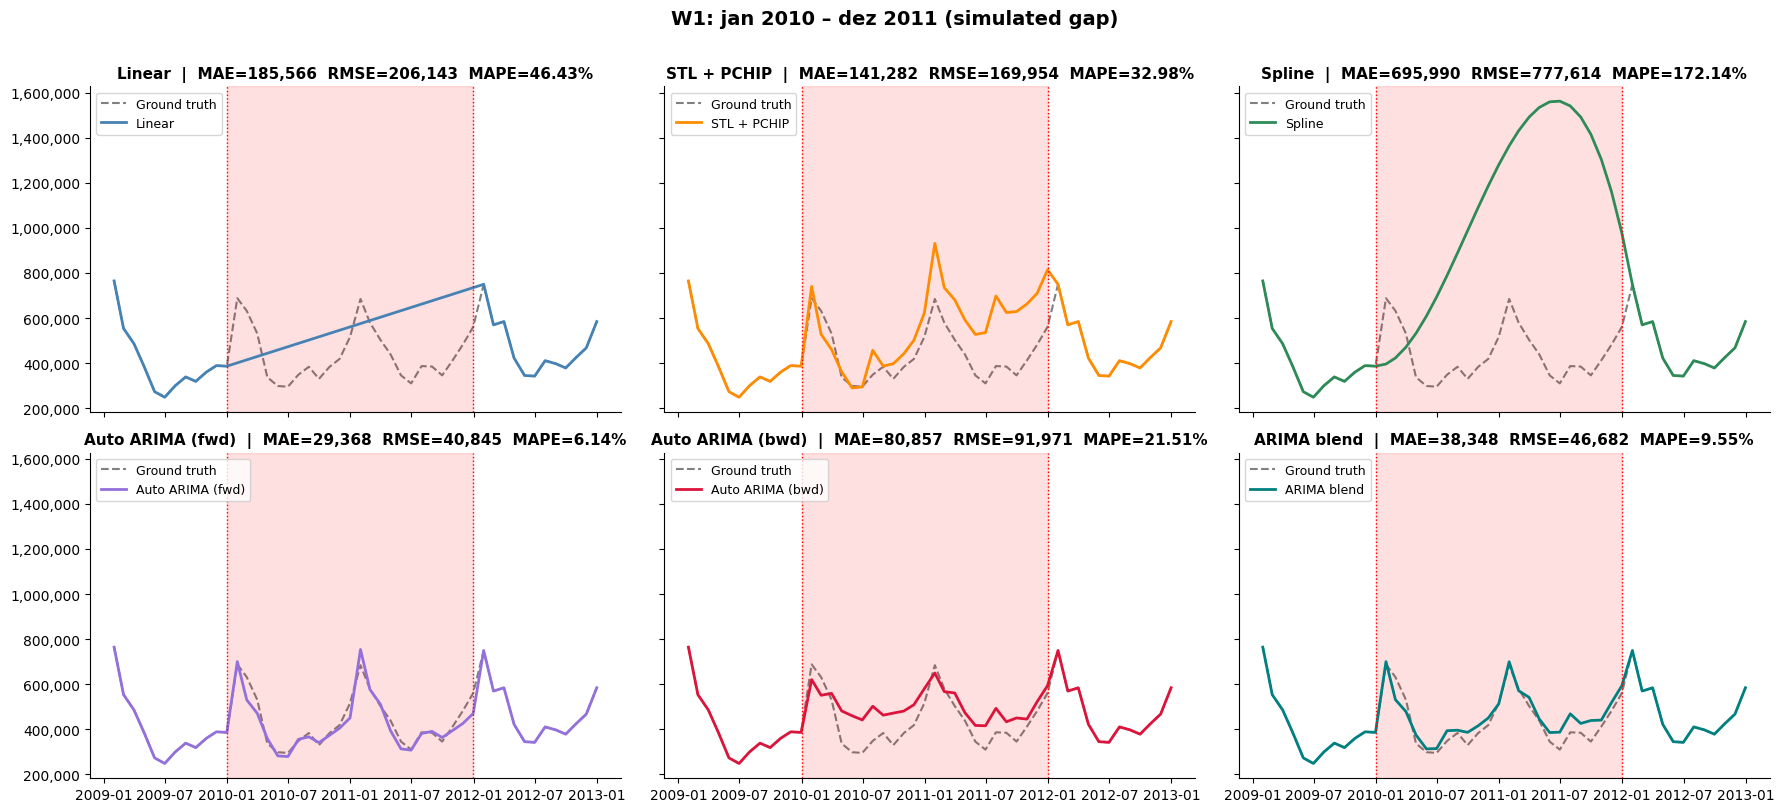

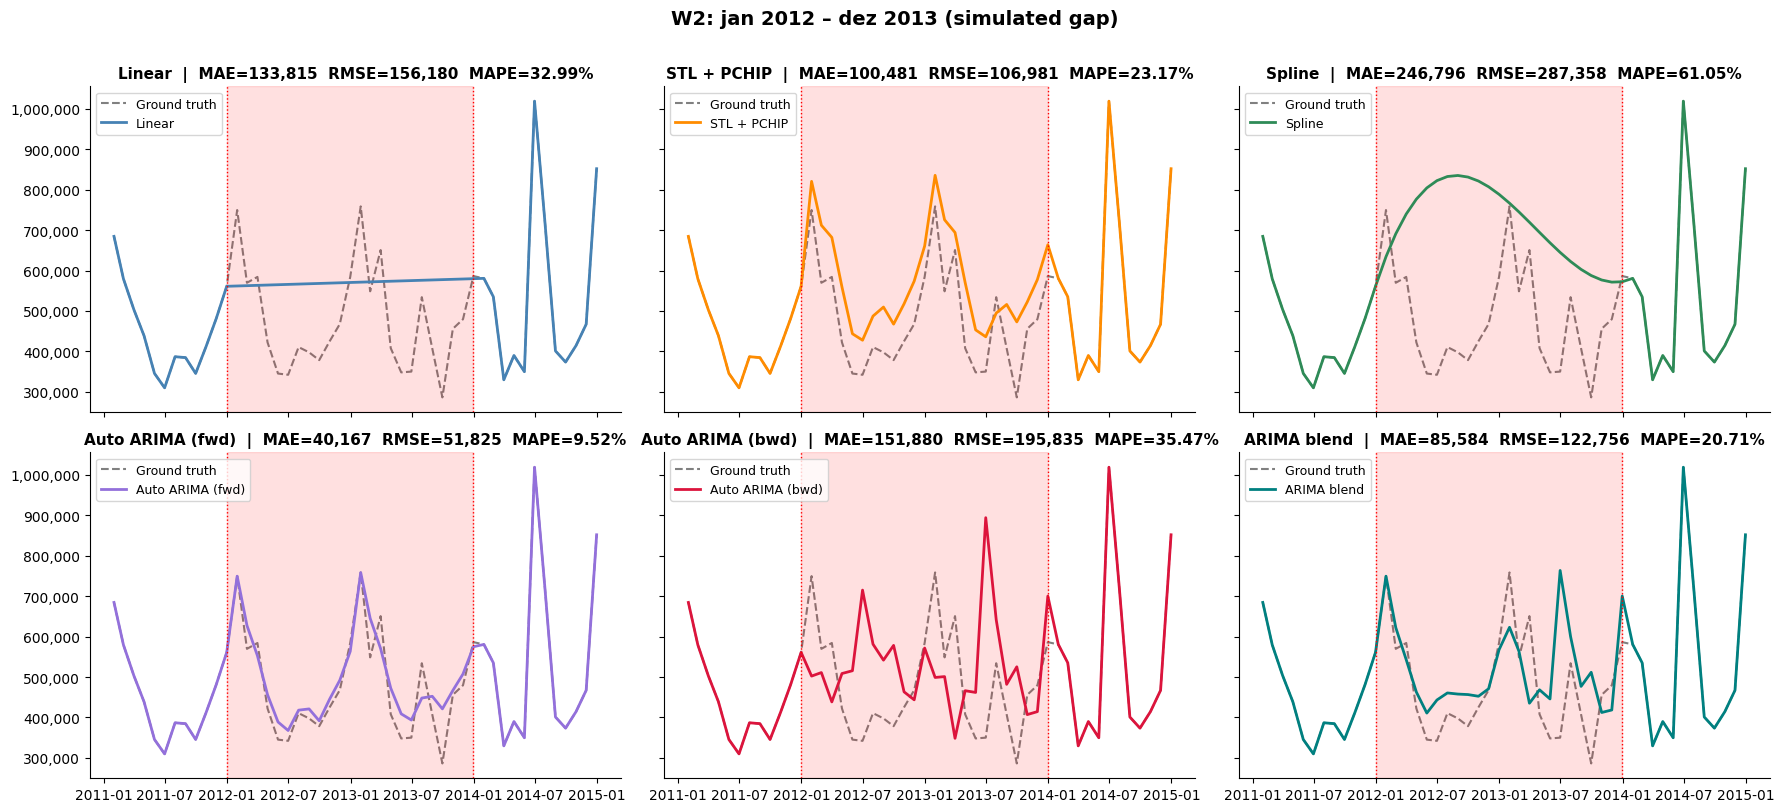

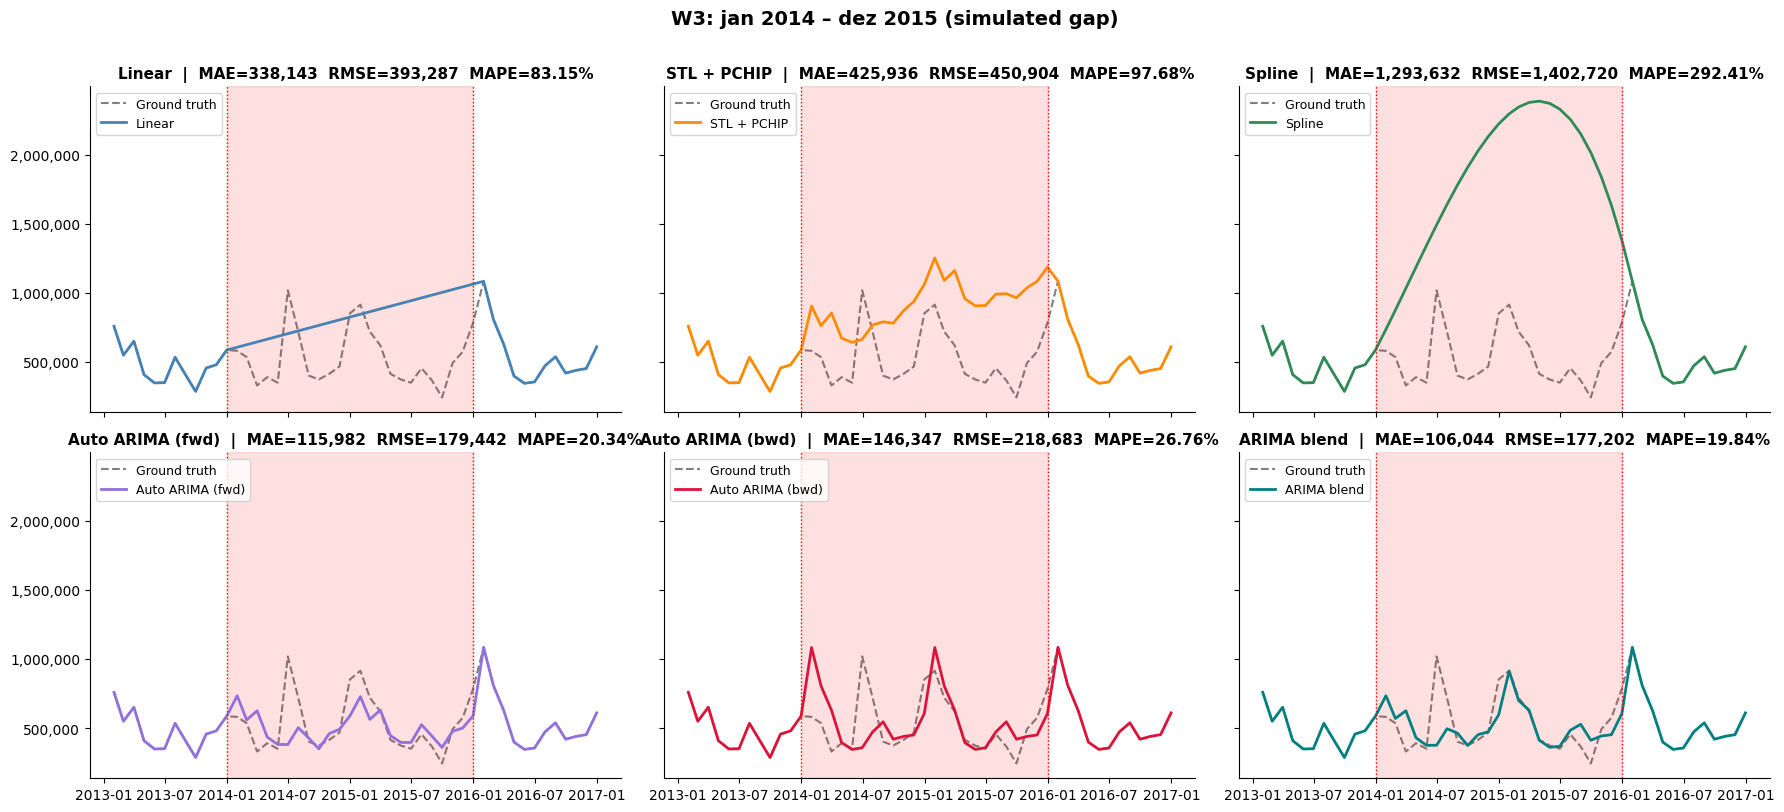

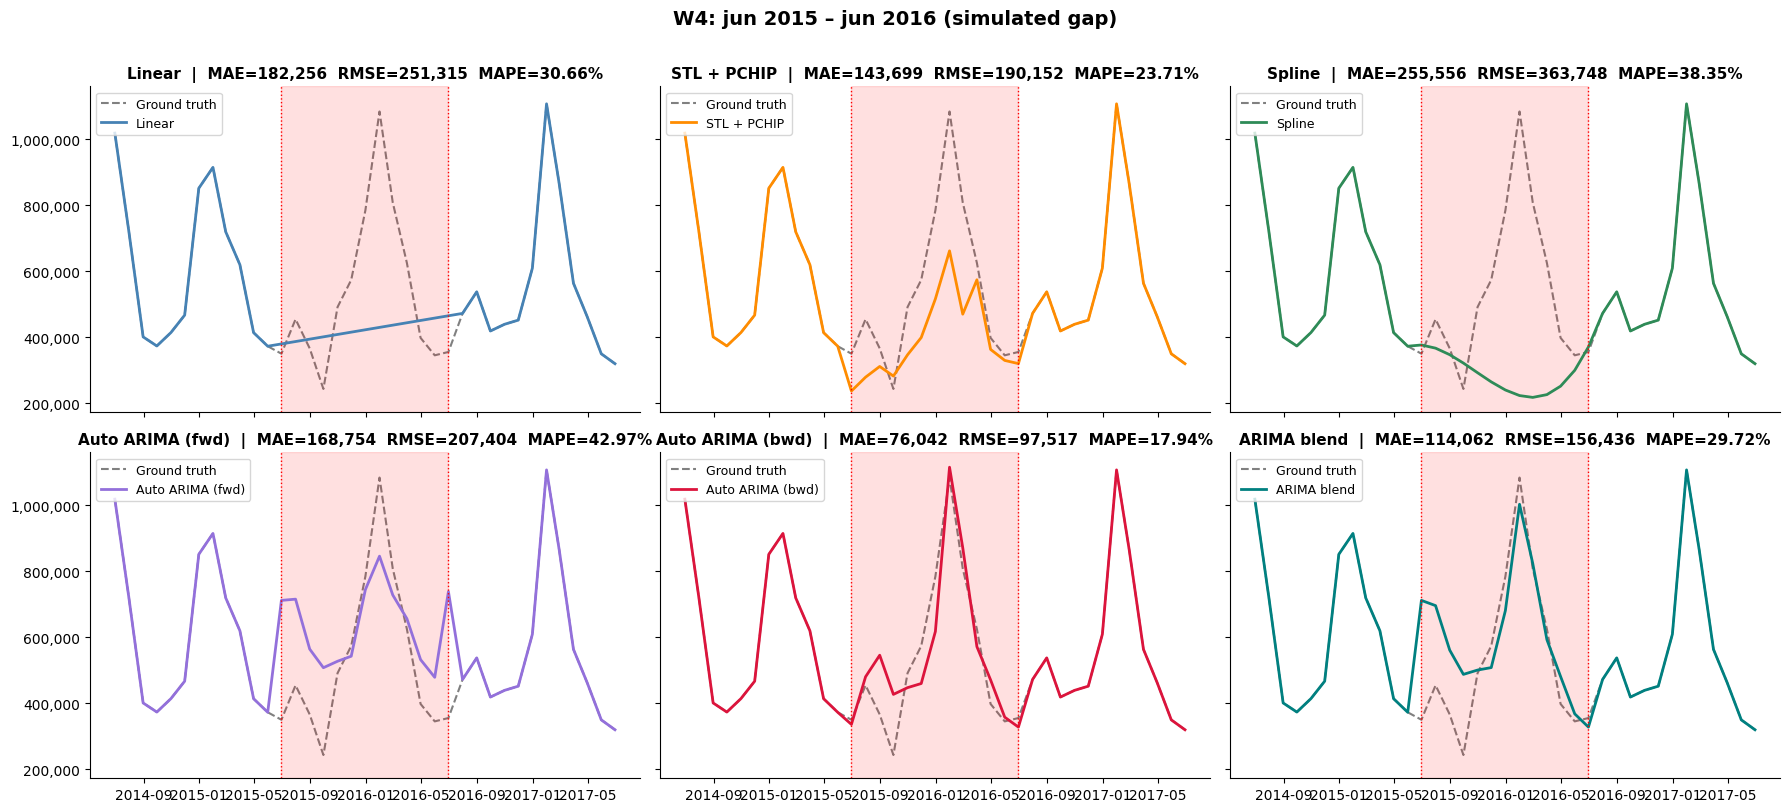

In [14]:
PLOT_BUFFER = pd.DateOffset(months=12)  # context shown around the gap

METHODS_TO_PLOT = [
    'Linear',
    'STL + PCHIP',
    'Spline',
    'Auto ARIMA (fwd)',
    'Auto ARIMA (bwd)',
    'ARIMA blend',
]

for win_name, gap_start, gap_end in WINDOWS:
    res = window_results[win_name]
    gap_mask = res['gap_mask']
    plot_start = gap_start - PLOT_BUFFER
    plot_end = gap_end + PLOT_BUFFER

    fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, method_name in zip(axes, METHODS_TO_PLOT):
        s_imputed = res[method_name]

        # original (ground truth) in grey dashes
        ax.plot(
            monthly_df[plot_start:plot_end].index,
            monthly_df.loc[plot_start:plot_end, 'arrival_count'],
            color='gray',
            linewidth=1.5,
            linestyle='--',
            label='Ground truth',
            zorder=1,
        )
        # imputed series
        color, ls = METHOD_STYLES[method_name]
        ax.plot(
            s_imputed[plot_start:plot_end].index,
            s_imputed[plot_start:plot_end],
            color=color,
            linewidth=2,
            linestyle=ls,
            label=method_name,
            zorder=2,
        )
        # gap region highlight
        ax.axvspan(gap_start, gap_end, alpha=0.12, color='red')
        ax.axvline(gap_start, color='red', linestyle=':', linewidth=1)
        ax.axvline(gap_end, color='red', linestyle=':', linewidth=1)

        # metrics annotation
        win_metrics = results_df[
            (results_df['Window'] == win_name) & (results_df['Method'] == method_name)
        ].iloc[0]
        ax.set_title(
            f'{method_name}  |  MAE={win_metrics["MAE"]:,.0f}  '
            f'RMSE={win_metrics["RMSE"]:,.0f}  MAPE={win_metrics["MAPE"]:.2f}%',
            fontsize=11,
            fontweight='bold',
        )
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
        ax.legend(loc='upper left', fontsize=9, frameon=True)
        sns.despine(ax=ax)

    fig.suptitle(
        f'{win_name}: {gap_start.strftime("%b %Y")} – {gap_end.strftime("%b %Y")} (simulated gap)',
        fontsize=14,
        fontweight='bold',
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

## Aggregated Results

In [15]:
summary = (
    results_df
    .groupby('Method')[['MAE', 'RMSE', 'MAPE']]
    .mean()
    .round({'MAE': 0, 'RMSE': 0, 'MAPE': 2})
    .sort_values('MAPE')
)
summary.index.name = 'Method'
summary.columns = ['Mean MAE', 'Mean RMSE', 'Mean MAPE (%)']

# rank by mean MAPE
summary.insert(0, 'Rank', range(1, len(summary) + 1))

print('\nAggregated benchmark (mean across 3 windows, sorted by MAPE)\n')
print(summary.to_string())
summary


Aggregated benchmark (mean across 3 windows, sorted by MAPE)

                  Rank  Mean MAE  Mean RMSE  Mean MAPE (%)
Method                                                    
Auto ARIMA (fwd)     1   88568.0   119879.0          19.74
ARIMA blend          2   86009.0   125769.0          19.95
Auto ARIMA (bwd)     3  113781.0   151002.0          25.42
STL + PCHIP          4  202850.0   229498.0          44.38
Linear               5  209945.0   251731.0          48.31
Spline               6  622993.0   707860.0         140.99


,Rank,Mean MAE,Mean RMSE,Mean MAPE (%)
Method,,,,
Auto ARIMA (fwd),1,88568.0,119879.0,19.74
ARIMA blend,2,86009.0,125769.0,19.95
Auto ARIMA (bwd),3,113781.0,151002.0,25.42
STL + PCHIP,4,202850.0,229498.0,44.38
Linear,5,209945.0,251731.0,48.31
Spline,6,622993.0,707860.0,140.99


## Method Comparison Plot

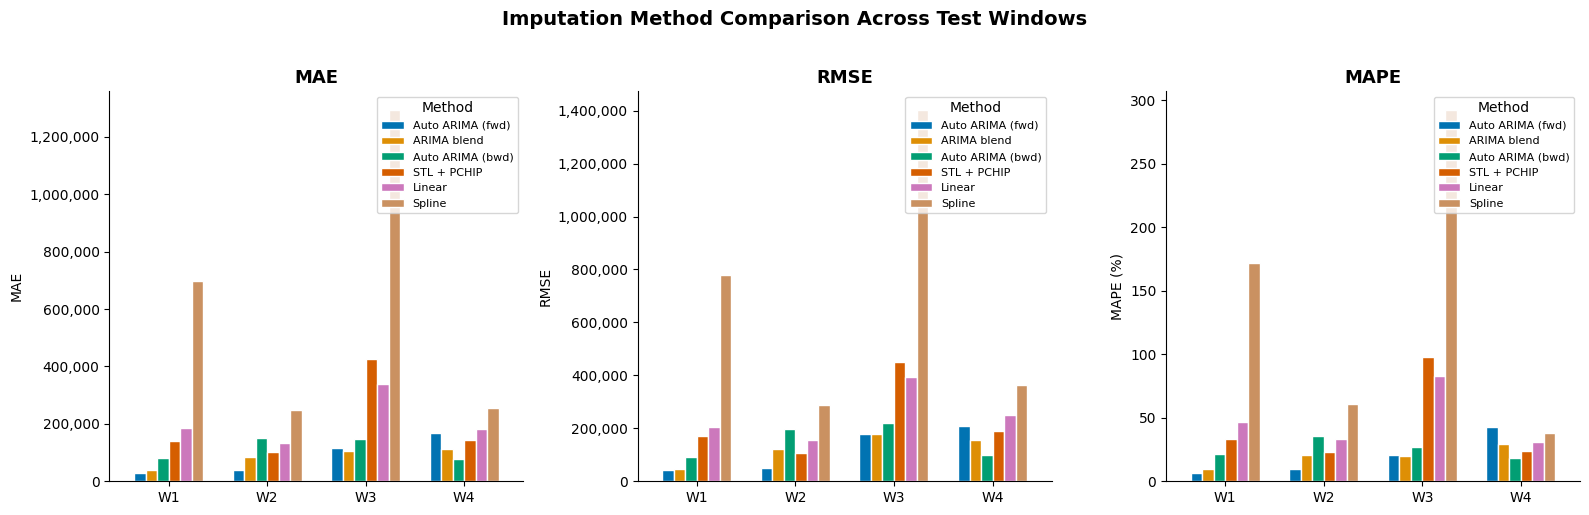

In [16]:
metrics = ['MAE', 'RMSE', 'MAPE']
method_order = summary.index.tolist()  # already ranked by mean MAPE

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metrics):
    pivot = results_df.pivot(index='Window', columns='Method', values=metric)[
        method_order
    ]
    pivot.plot(kind='bar', ax=ax, width=0.7, edgecolor='white')

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metric + (' (%)' if metric == 'MAPE' else ''))
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Method', fontsize=8, loc='upper right')
    if metric != 'MAPE':
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(ax=ax)

fig.suptitle(
    'Imputation Method Comparison Across Test Windows',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
plt.show()

## Conclusion

The table above ranks the six methods by mean MAPE across the four simulated windows. The best-performing method — lowest rank — is the recommended choice for imputing the COVID-19 gap (2020-01 → 2021-12) in the final dataset.